In [ ]:
import pandas as pd

# Load the dataset
# Make sure the file name matches exactly what you uploaded
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 1. Dataset preview (head)
print("--- Dataset Preview (head()) ---")
display(df.head())

# 2. Dataset summary (info)
print("\n--- Dataset Summary (info()) ---")
df.info()

--- Dataset Preview (head()) ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Dataset Summary (info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperles

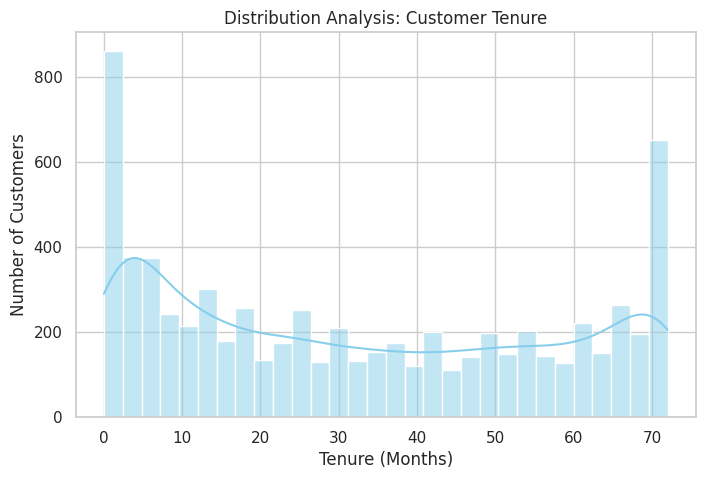

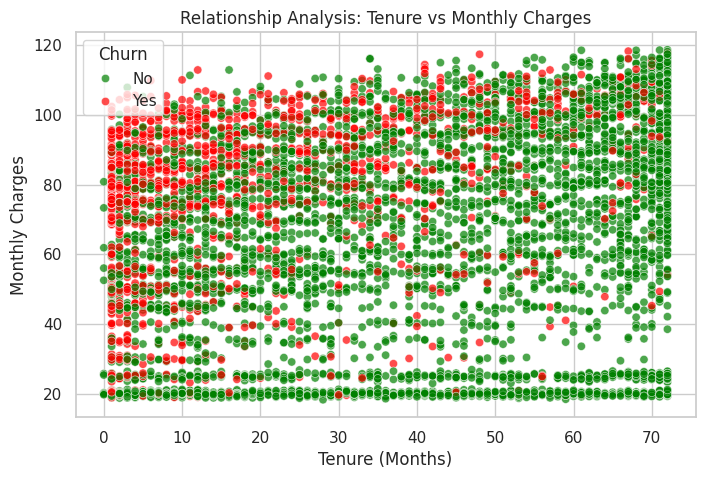

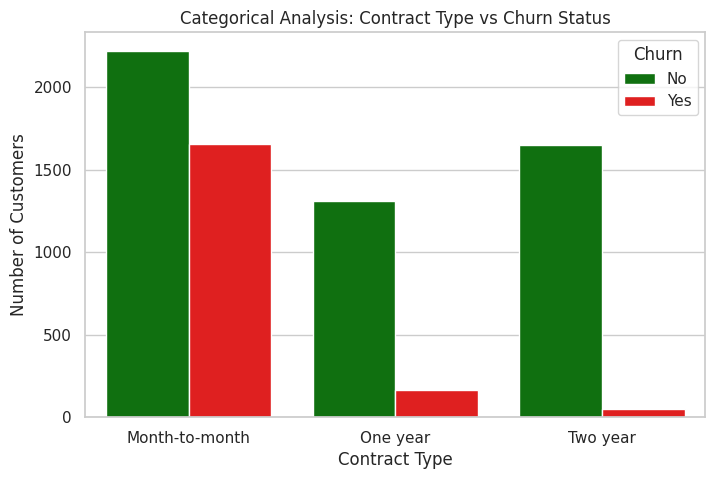

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.histplot(df['tenure'], bins=30, kde=True, color='skyblue')
plt.title('Distribution Analysis: Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', palette={'Yes': 'red', 'No': 'green'}, alpha=0.7)
plt.title('Relationship Analysis: Tenure vs Monthly Charges')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')
plt.legend(title='Churn')
plt.show()
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette={'Yes': 'red', 'No': 'green'})
plt.title('Categorical Analysis: Contract Type vs Churn Status')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
print("Check 1: Missing values and blank spaces")
missing_values = df.isnull().sum()
blank_spaces = (df == ' ').sum()
print("Missing values per column:")
print(missing_values)
print("\nBlank spaces per column:")
print(blank_spaces)
print("\nCheck 2: Duplicate records")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Check 1: Missing values and blank spaces
Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Blank spaces per column:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges   

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 1. Drop customerID as it has no predictive value
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# 2. Clean TotalCharges (converts blank spaces to NaN, then fills with median)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 3. Categorical Encoding
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns before encoding:", cat_cols)

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convert boolean columns to integers (0 and 1)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Rename target variable back to 'Churn'
if 'Churn_Yes' in df_encoded.columns:
    df_encoded.rename(columns={'Churn_Yes': 'Churn'}, inplace=True)

print("\nDataset shape after encoding:", df_encoded.shape)
display(df_encoded.head())

# 4. Feature Scaling
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("\nDataset summary after scaling:")
display(df_encoded[num_cols].describe())

Categorical columns before encoding: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

Dataset shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1



Dataset summary after scaling:


,tenure,MonthlyCharges,TotalCharges
count,7.043000e+03,7.043000e+03,7.043000e+03
mean,-2.421273e-17,-6.406285e-17,-1.488074e-17
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00,-9.991203e-01
25%,-9.516817e-01,-9.725399e-01,-8.298459e-01
50%,-1.372744e-01,1.857327e-01,-3.904632e-01
75%,9.214551e-01,8.338335e-01,6.642871e-01
max,1.613701e+00,1.794352e+00,2.826743e+00


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 1. Drop customerID as it has no predictive value
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# 2. Clean TotalCharges (converts blank spaces to NaN, then fills with median)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 3. Categorical Encoding
cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convert boolean columns to integers (0 and 1)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Rename target variable back to 'Churn'
if 'Churn_Yes' in df_encoded.columns:
    df_encoded.rename(columns={'Churn_Yes': 'Churn'}, inplace=True)

print("Dataset shape after encoding:", df_encoded.shape)

# --- NEW: Split columns into two halves for better screenshots ---
mid_point = len(df_encoded.columns) // 2
first_half_cols = df_encoded.columns[:mid_point]
second_half_cols = df_encoded.columns[mid_point:]

print("\n--- First Half of Columns ---")
display(df_encoded[first_half_cols].head())

print("\n--- Second Half of Columns ---")
display(df_encoded[second_half_cols].head())

# 4. Feature Scaling
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("\nDataset summary after scaling:")
display(df_encoded[num_cols].describe())

Dataset shape after encoding: (7043, 31)

--- First Half of Columns ---


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service
0,0,1,29.85,29.85,0,1,0,0,1,0,0,0,0,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,0,0,0,1,0
3,0,45,42.30,1840.75,1,0,0,0,1,0,0,0,0,1,0
4,0,2,70.70,151.65,0,0,0,1,0,0,1,0,0,0,0



--- Second Half of Columns ---


,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0
1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0
2,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1
3,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1



Dataset summary after scaling:


,tenure,MonthlyCharges,TotalCharges
count,7.043000e+03,7.043000e+03,7.043000e+03
mean,-2.421273e-17,-6.406285e-17,-1.488074e-17
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00,-9.991203e-01
25%,-9.516817e-01,-9.725399e-01,-8.298459e-01
50%,-1.372744e-01,1.857327e-01,-3.904632e-01
75%,9.214551e-01,8.338335e-01,6.642871e-01
max,1.613701e+00,1.794352e+00,2.826743e+00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

if 'Churn_Yes' in df_encoded.columns:
    df_encoded.rename(columns={'Churn_Yes': 'Churn'}, inplace=True)

print("Dataset shape after encoding:", df_encoded.shape)
print("Total columns:", len(df_encoded.columns))

# Split into 4 parts and show each
chunks = np.array_split(df_encoded.columns, 4)

for i, chunk in enumerate(chunks):
    print(f"\n{'='*60}")
    print(f"Part {i+1} of 4 - Columns: {len(chunk)}")
    print(f"Column names: {chunk.tolist()}")
    print(f"{'='*60}")
    display(df_encoded[chunk].head())

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("\n\nDataset summary after scaling:")
display(df_encoded[num_cols].describe())

Dataset shape after encoding: (7043, 31)
Total columns: 31

Part 1 of 4 - Columns: 8
Column names: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes
0,0,1,29.85,29.85,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1
2,0,2,53.85,108.15,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0
4,0,2,70.70,151.65,0,0,0,1



Part 2 of 4 - Columns: 8
Column names: ['MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes']


,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes
0,1,0,0,0,0,0,0,1
1,0,0,0,0,0,1,0,0
2,0,0,0,0,0,1,0,1
3,1,0,0,0,0,1,0,0
4,0,0,1,0,0,0,0,0



Part 3 of 4 - Columns: 8
Column names: ['DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes']


,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0
3,0,1,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0



Part 4 of 4 - Columns: 7
Column names: ['Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'Churn']


,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,0,1,0,1,0,0
1,1,0,0,0,0,1,0
2,0,0,1,0,0,1,1
3,1,0,0,0,0,0,0
4,0,0,1,0,1,0,1




Dataset summary after scaling:


,tenure,MonthlyCharges,TotalCharges
count,7.043000e+03,7.043000e+03,7.043000e+03
mean,-2.421273e-17,-6.406285e-17,-1.488074e-17
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00,-9.991203e-01
25%,-9.516817e-01,-9.725399e-01,-8.298459e-01
50%,-1.372744e-01,1.857327e-01,-3.904632e-01
75%,9.214551e-01,8.338335e-01,6.642871e-01
max,1.613701e+00,1.794352e+00,2.826743e+00


Baseline Accuracy: 0.7069
              precision    recall  f1-score   support

    No Churn       0.80      0.80      0.80      1036
       Churn       0.45      0.45      0.45       373

    accuracy                           0.71      1409
   macro avg       0.62      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409

[[827 209]
 [204 169]]


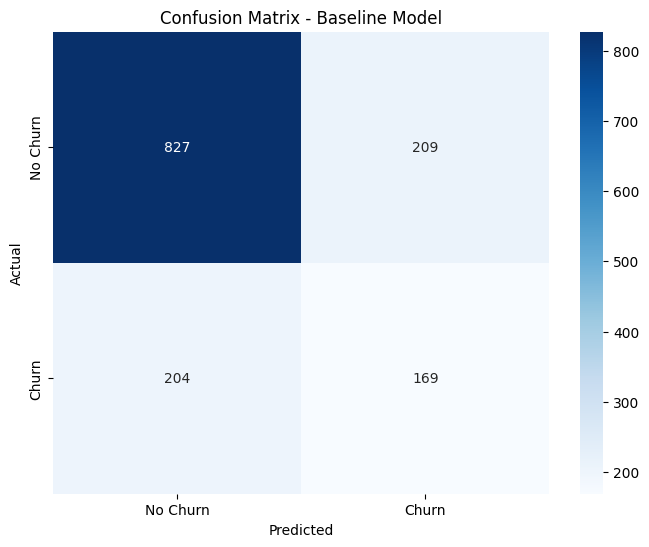

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Baseline Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Dataset shape: (7043, 31)

Training set size: 5634
Testing set size: 1409

Accuracy: 0.8211

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.90      0.88      1036
       Churn       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409


Confusion Matrix:
[[934 102]
 [150 223]]


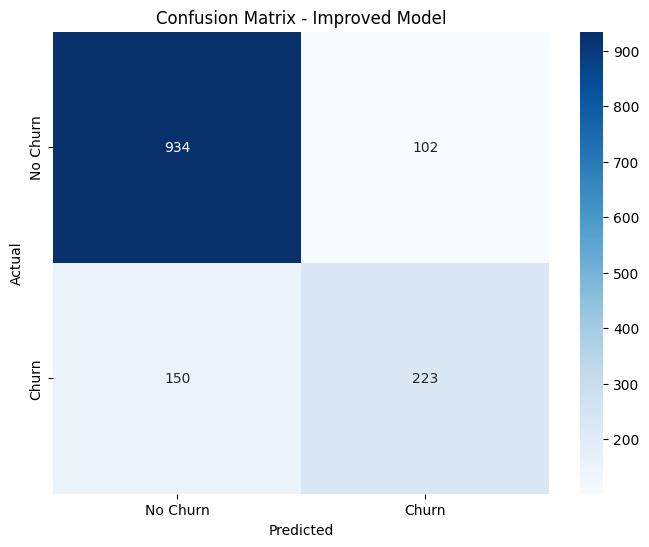

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

if 'Churn_Yes' in df_encoded.columns:
    df_encoded.rename(columns={'Churn_Yes': 'Churn'}, inplace=True)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("Dataset shape:", df_encoded.shape)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining set size:", len(X_train))
print("Testing set size:", len(X_test))

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Improved Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [5]:
import pandas as pd
import numpy as np

def validate_dataset(df, dataset_name="Dataset"):
    """
    Automated Data Validation Script
    Checks: Missing values, Duplicates, Data Types, Value Ranges
    """
    print("="*70)
    print(f"AUTOMATED DATA VALIDATION REPORT: {dataset_name}")
    print("="*70)

    # Check 1: Missing Values
    print("\n[CHECK 1] MISSING VALUES")
    print("-" * 40)
    missing_values = df.isnull().sum()
    missing_columns = missing_values[missing_values > 0]

    if len(missing_columns) == 0:
        print("PASS: No missing values found")
    else:
        print("FAIL: Missing values detected")
        for col, count in missing_columns.items():
            print(f"  - {col}: {count} missing values ({count/len(df)*100:.2f}%)")

    # Check 2: Duplicate Rows
    print("\n[CHECK 2] DUPLICATE ROWS")
    print("-" * 40)
    duplicates = df.duplicated().sum()

    if duplicates == 0:
        print("PASS: No duplicate rows found")
    else:
        print(f"FAIL: {duplicates} duplicate rows detected")

    # Check 3: Data Type Consistency
    print("\n[CHECK 3] DATA TYPE VALIDATION")
    print("-" * 40)
    print("Column Data Types:")
    for col, dtype in df.dtypes.items():
        print(f"  - {col}: {dtype}")

    # Check for potential type issues
    object_cols = df.select_dtypes(include=['object']).columns
    if len(object_cols) > 0:
        print(f"WARNING: {len(object_cols)} categorical columns detected")
        print(f"  Columns: {list(object_cols)}")

    # Check 4: Value Range Validation (for numerical columns)
    print("\n[CHECK 4] VALUE RANGE VALIDATION")
    print("-" * 40)
    numerical_cols = df.select_dtypes(include=[np.number]).columns

    range_issues = []
    for col in numerical_cols:
        min_val = df[col].min()
        max_val = df[col].max()

        # Check for negative values where they shouldn't exist
        if col in ['tenure', 'TotalCharges', 'MonthlyCharges']:
            if min_val < 0:
                range_issues.append(f"{col}: Contains negative values (min={min_val})")

        print(f"  - {col}: Range [{min_val:.2f}, {max_val:.2f}]")

    if len(range_issues) == 0:
        print("PASS: No invalid value ranges detected")
    else:
        print("FAIL: Invalid value ranges detected")
        for issue in range_issues:
            print(f"  - {issue}")

    # Check 5: Summary Statistics
    print("\n[CHECK 5] DATA QUALITY SUMMARY")
    print("-" * 40)
    total_cells = df.shape[0] * df.shape[1]
    total_missing = df.isnull().sum().sum()
    completeness = ((total_cells - total_missing) / total_cells) * 100

    print(f"Total Records: {df.shape[0]}")
    print(f"Total Features: {df.shape[1]}")
    print(f"Data Completeness: {completeness:.2f}%")

    # Overall Validation Result
    print("\n" + "="*70)
    print("OVERALL VALIDATION RESULT")
    print("="*70)

    total_issues = len(missing_columns) + (1 if duplicates > 0 else 0) + len(range_issues)

    if total_issues == 0:
        print("ALL CHECKS PASSED, Dataset is ready for analysis")
    else:
        print(f"⚠ {total_issues} ISSUE(S) DETECTED, Review required before analysis")

    print("="*70)

    return {
        'missing_values': len(missing_columns),
        'duplicates': duplicates,
        'range_issues': len(range_issues),
        'total_issues': total_issues
    }

# Load and validate the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
validation_results = validate_dataset(df, "Telco Customer Churn")

AUTOMATED DATA VALIDATION REPORT: Telco Customer Churn

[CHECK 1] MISSING VALUES
----------------------------------------
PASS: No missing values found

[CHECK 2] DUPLICATE ROWS
----------------------------------------
PASS: No duplicate rows found

[CHECK 3] DATA TYPE VALIDATION
----------------------------------------
Column Data Types:
  - customerID: object
  - gender: object
  - SeniorCitizen: int64
  - Partner: object
  - Dependents: object
  - tenure: int64
  - PhoneService: object
  - MultipleLines: object
  - InternetService: object
  - OnlineSecurity: object
  - OnlineBackup: object
  - DeviceProtection: object
  - TechSupport: object
  - StreamingTV: object
  - StreamingMovies: object
  - Contract: object
  - PaperlessBilling: object
  - PaymentMethod: object
  - MonthlyCharges: float64
  - TotalCharges: object
  - Churn: object
  Columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', '